# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan

- Nama: Agil Firli Gunawan
- Email: agilfirli29@gmail.com
- Id Dicoding: agilfirligunawan

## Persiapan

### Menyiapkan library yang dibutuhkan

In [4]:
import warnings
warnings.filterwarnings('ignore')
import os

import numpy as np
import pandas as pd

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import RandomOverSampler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

### Menyiapkan data yang akan digunakan

In [11]:
dataset = "https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/main/students_performance/data.csv"
df = pd.read_csv(dataset, delimiter=';')

## Data Understanding

In [12]:
# Mengecek baris pertama
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [13]:
# Melihat Info Dataset
dataset = df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [16]:
# Mengecek missing values pada setiap kolom
missing_values = df.isnull().sum()
missing_values

,0
Marital_status,0
Application_mode,0
Application_order,0
Course,0
Daytime_evening_attendance,0
Previous_qualification,0
Previous_qualification_grade,0
Nacionality,0
Mothers_qualification,0
Fathers_qualification,0


In [17]:
# Mengecek duplikat pada setiap kolom
duplicate_count = df.duplicated().sum()
print("Jumlah duplikasi: ", duplicate_count)

Jumlah duplikasi:  0


In [18]:
#Statistik Deskriptif
df.describe()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,10.960895,11.032324,126.978119,0.548373,0.011528,0.113698,0.880651,0.351718,0.248418,23.265145,0.024864,0.709991,6.270570,8.299051,4.706600,10.640822,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,26.418253,25.263040,14.482001,0.497711,0.106760,0.317480,0.324235,0.477560,0.432144,7.587816,0.155729,2.360507,2.480178,4.179106,3.094238,4.843663,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,0.000000,0.000000,95.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,4.000000,4.000000,117.900000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,19.000000,0.000000,0.000000,5.000000,6.000000,3.000000,11.000000,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,5.000000,7.000000,126.100000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,20.000000,0.000000,0.000000,6.000000,8.000000,5.000000,12.285714,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,9.000000,9.000000,134.800000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,25.000000,0.000000,0.000000,7.000000,10.000000,6.000000,13.400000,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,194.000000,195.000000,190.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,70.000000,1.000000,20.000000,26.000000,45.000000,26.000000,18.875000,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


**Insight:**
- Dataset terdiri dari 4424 baris dan 37 kolom.
- Tipe data terdiri dari numerik (int64, float64) dan kategorikal (object). Secara rinci, terdapat 29 kolom bertipe int64, 7 kolom bertipe float64, dan 1 kolom bertipe object yang merupakan kolom target (Status).
- Tidak terdapat missing values (nilai kosong) pada satupun kolom dalam dataset ini. Hal ini berarti data sudah sangat bersih dari kekosongan informasi sehingga kita tidak perlu melakukan tahapan imputasi atau penghapusan baris akibat missing values.
- Tidak ada data duplikat dalam dataset ini.
- Berdasarkan ringkasan statistik deskriptif, seluruh kolom numerik memiliki variasi nilai (dilihat dari nilai standar deviasi yang lebih dari 0). Oleh karena itu, tidak terdapat kolom yang nilainya konstan (hanya satu nilai), sehingga tidak ada kolom yang harus langsung dihapus pada tahap awal ini karena semuanya memiliki variasi data yang berpotensi berguna untuk model Machine Learning.

## Data Preparation / Preprocessing

Membersihkan Data dan Ekspor untuk Dashboard (Sel Kode)

In [20]:
def prepare_dashboard_data(dataframe):
    df_vis = dataframe.copy()

    # Mapping untuk riwayat pendidikan orang tua dan mahasiswa
    map_qualifications = {
        1: 'Secondary education', 2: "Higher education - bachelor's degree", 3: 'Higher education - degree',
        4: "Higher education - master's", 5: 'Higher education - doctorate', 6: 'Frequency of higher education',
        9: '12th year of schooling - not completed', 10: '11th year of schooling - not completed',
        11: '7th Year (Old)', 12: 'Other - 11th year of schooling', 14: '10th year of schooling',
        15: '10th year of schooling - not completed', 18: 'General Commerce Course',
        19: 'Basic education 3rd cycle (9th/10th/11th year) or equiv.', 22: 'Technical-Professional Course',
        26: '7th Year of Schooling', 27: '2nd Cycle of the General High School Course',
        29: '9th Year of Schooling - Not Completed', 30: '8th Year of Schooling', 34: 'Unknown',
        35: "Can't Read or Write", 36: 'Can Read Without Having a 4th Year of Schooling',
        37: 'Basic Education 1st Cycle (4th/5th Year) or Equiv.', 38: 'Basic education 2nd cycle (6th/7th/8th year) or equiv.',
        39: 'Technological specialization course', 40: 'Higher education - degree (1st cycle)',
        41: 'Specialized Higher Studies Course', 42: 'Professional higher technical course',
        43: 'Higher education - master (2nd cycle)', 44: 'Higher Education - Doctorate (3rd Cycle)'
    }

    # Mapping untuk profesi pekerjaan orang tua (beberapa teks dipersingkat agar grafik rapi)
    map_occupations = {
        0: 'Student', 1: 'Representatives of the Legislative Power and Executive Bodies...',
        2: 'Specialists in Intellectual and Scientific Activities', 3: 'Intermediate Level Technicians and Professions',
        4: 'Administrative staff', 5: 'Personal Services, Security and Safety Workers and Sellers',
        6: 'Farmers and Skilled Workers in Agriculture, Fisheries and Forestry',
        7: 'Skilled Workers in Industry, Construction and Craftsmen',
        8: 'Installation and Machine Operators and Assembly Workers', 9: 'Unskilled Workers',
        10: 'Armed Forces Professions', 90: 'Other Situation', 99: '(blank)', 101: 'Armed Forces Officers',
        102: 'Armed Forces Sergeants', 103: 'Other Armed Forces personnel',
        112: 'Directors of administrative and commercial services',
        114: 'Hotel, catering, trade and other services directors',
        121: 'Specialists in the physical sciences, mathematics, engineering and related techniques',
        122: 'Health professionals', 123: 'Teachers',
        124: 'Specialists in finance, accounting, administrative organization, public and commercial relations',
        131: 'Intermediate level science and engineering technicians and professions',
        132: 'Technicians and professionals, of intermediate level of health',
        134: 'Intermediate level technicians from legal, social, sports, cultural and similar services',
        135: 'Information and communication technology technicians',
        141: 'Office workers, secretaries in general and data processing operators',
        143: 'Data, accounting, statistical, financial services and registry-related operators',
        144: 'Other administrative support staff', 151: 'Personal service workers', 152: 'Sellers',
        153: 'Personal care workers and the like', 154: 'Protection and security services personnel',
        161: 'Market-oriented farmers and skilled agricultural and animal production workers',
        163: 'Farmers, livestock keepers, fishermen, hunters and gatherers, subsistence',
        171: 'Skilled construction workers and the like, except electricians',
        172: 'Skilled workers in metallurgy, metalworking and similar',
        174: 'Skilled workers in electricity and electronics',
        175: 'Workers in food processing, woodworking, clothing and other industries and crafts',
        181: 'Fixed plant and machine operators', 182: 'Assembly workers',
        183: 'Vehicle drivers and mobile equipment operators',
        192: 'Unskilled workers in agriculture, animal production, fisheries and forestry',
        193: 'Unskilled workers in extractive industry, construction, manufacturing and transport',
        194: 'Meal preparation assistants', 195: 'Street vendors (except food) and street service providers'
    }

    # Aturan utama: menyatukan semua dictionary berdasarkan kolom masing-masing
    decode_rules = {
        'Marital_status': {1: 'single', 2: 'married', 3: 'widower', 4: 'divorced', 5: 'facto union', 6: 'legally separated'},
        'Daytime_evening_attendance': {1: 'daytime', 0: 'evening'},
        'Mothers_qualification': map_qualifications,
        'Fathers_qualification': map_qualifications,
        'Previous_qualification': map_qualifications,
        'Mothers_occupation': map_occupations,
        'Fathers_occupation': map_occupations,
        'Application_mode': {
            1: '1st phase - general contingent', 2: 'Ordinance No. 612/93', 5: '1st phase - special contingent (Azores Island)',
            7: 'Holders of other higher courses', 10: 'Ordinance No. 854-B/99', 15: 'International student (bachelor)',
            16: '1st phase - special contingent (Madeira Island)', 17: '2nd phase - general contingent',
            18: '3rd phase - general contingent', 26: 'Ordinance No. 533-A/99, item b2) (Different Plan)',
            27: 'Ordinance No. 533-A/99, item b3 (Other Institution)', 39: 'Over 23 years old', 42: 'Transfer',
            43: 'Change of course', 44: 'Technological specialization diploma holders',
            51: 'Change of institution/course', 53: 'Short cycle diploma holders',
            57: 'Change of institution/course (International)'
        },
        'Course': {
            33: 'Biofuel Production Technologies', 171: 'Animation and Multimedia Design',
            8014: 'Social Service (evening attendance)', 9003: 'Agronomy', 9070: 'Communication Design',
            9085: 'Veterinary Nursing', 9119: 'Informatics Engineering', 9130: 'Equinculture',
            9147: 'Management', 9238: 'Social Service', 9254: 'Tourism', 9500: 'Nursing',
            9556: 'Oral Hygiene', 9670: 'Advertising and Marketing Management',
            9773: 'Journalism and Communication', 9853: 'Basic Education', 9991: 'Management (evening attendance)'
        },
        'Nacionality': {
            1: 'Portuguese', 2: 'German', 6: 'Spanish', 11: 'Italian', 13: 'Dutch', 14: 'English',
            17: 'Lithuanian', 21: 'Angolan', 22: 'Cape Verdean', 24: 'Guinean', 25: 'Mozambican',
            26: 'Santomean', 32: 'Turkish', 41: 'Brazilian', 62: 'Romanian', 100: 'Moldova (Republic of)',
            101: 'Mexican', 103: 'Ukrainian', 105: 'Russian', 108: 'Cuban', 109: 'Colombian'
        }
    }

    # Mengeksekusi perubahan nilai secara serentak (jauh lebih efisien dari metode .map per baris)
    df_vis.replace(decode_rules, inplace=True)
    return df_vis

# Terapkan fungsi pada dataset dan tampilkan 5 baris pertama
decoded_df = prepare_dashboard_data(df)
decoded_df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,single,2nd phase - general contingent,5,Animation and Multimedia Design,daytime,Secondary education,122.0,Portuguese,Basic education 3rd cycle (9th/10th/11th year)...,Other - 11th year of schooling,"Personal Services, Security and Safety Workers...",Unskilled Workers,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,single,International student (bachelor),1,Tourism,daytime,Secondary education,160.0,Portuguese,Secondary education,Higher education - degree,Intermediate Level Technicians and Professions,Intermediate Level Technicians and Professions,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,single,1st phase - general contingent,5,Communication Design,daytime,Secondary education,122.0,Portuguese,Basic Education 1st Cycle (4th/5th Year) or Eq...,Basic Education 1st Cycle (4th/5th Year) or Eq...,Unskilled Workers,Unskilled Workers,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,single,2nd phase - general contingent,2,Journalism and Communication,daytime,Secondary education,122.0,Portuguese,Basic education 2nd cycle (6th/7th/8th year) o...,Basic Education 1st Cycle (4th/5th Year) or Eq...,"Personal Services, Security and Safety Workers...",Intermediate Level Technicians and Professions,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,married,Over 23 years old,1,Social Service (evening attendance),evening,Secondary education,100.0,Portuguese,Basic Education 1st Cycle (4th/5th Year) or Eq...,Basic education 2nd cycle (6th/7th/8th year) o...,Unskilled Workers,Unskilled Workers,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [21]:
# Cek proporsi jumlah mahasiswa berdasarkan status akhirnya (sebelum data dibersihkan)
df['Status'].value_counts()

,count
Status,
Graduate,2209
Dropout,1421
Enrolled,794


In [22]:
# Hapus mahasiswa berstatus 'Enrolled' (masih kuliah) karena fokus pemodelan kita hanya memprediksi hasil akhir (Dropout atau Graduate)
df = df[df['Status'] != 'Enrolled'].copy()

# Pastikan status 'Enrolled' sudah berhasil dihapus
df['Status'].value_counts()

,count
Status,
Graduate,2209
Dropout,1421


In [23]:
# Mengubah kelas target ke bentuk numerik biner agar bisa diproses algoritma ML
df['Status'] = df['Status'].replace({'Graduate': 0, 'Dropout': 1})

# Ambil 3 sampel acak untuk mengecek apakah target sudah berubah menjadi angka
df.sample(3)

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
302,1,1,1,9500,1,1,160.0,1,19,19,4,9,154.4,0,0,0,1,0,1,18,0,0,7,9,7,15.116667,0,0,8,9,8,16.168889,0,15.5,2.8,-4.06,0
1486,1,53,1,9085,1,42,140.0,1,1,3,4,2,142.8,1,0,0,0,0,1,20,0,7,12,15,11,13.384615,0,4,9,13,7,14.285714,0,8.9,1.4,3.51,0
3965,1,1,3,9500,1,1,150.0,1,19,19,5,5,132.8,1,0,0,1,0,1,18,0,0,8,8,8,13.011250,0,0,8,8,8,13.011250,0,9.4,-0.8,-3.12,0


In [24]:
decoded_df.sample(3)

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
1256,single,2nd phase - general contingent,1,Social Service,daytime,Secondary education,115.0,Portuguese,Basic education 3rd cycle (9th/10th/11th year)...,Basic education 2nd cycle (6th/7th/8th year) o...,"Personal Services, Security and Safety Workers...","Personal Services, Security and Safety Workers...",115.0,1,0,0,1,0,0,19,0,0,6,6,6,12.0,0,0,6,7,6,12.857143,0,11.1,0.6,2.02,Graduate
121,single,1st phase - general contingent,2,Management,daytime,Secondary education,120.0,Portuguese,Basic education 3rd cycle (9th/10th/11th year)...,Basic education 3rd cycle (9th/10th/11th year)...,Unskilled Workers,"Skilled Workers in Industry, Construction and ...",118.6,1,0,0,1,0,0,19,0,0,5,8,5,10.8,0,0,5,9,4,11.250000,2,16.2,0.3,-0.92,Graduate
127,single,1st phase - general contingent,1,Basic Education,daytime,Secondary education,146.0,Portuguese,Basic education 3rd cycle (9th/10th/11th year)...,Basic education 2nd cycle (6th/7th/8th year) o...,Unskilled Workers,Intermediate Level Technicians and Professions,145.3,1,0,0,1,0,1,18,0,0,6,8,5,12.8,0,0,6,7,5,13.400000,0,9.4,-0.8,-3.12,Enrolled


In [25]:
# Membuat folder 'dataset' secara otomatis jika belum ada untuk menghindari error direktori tidak ditemukan
os.makedirs('./dataset', exist_ok=True)

# Menyimpan dataframe versi teks (decoded_df) khusus untuk keperluan visualisasi di Looker Studio
# index=False digunakan agar nomor baris bawaan Pandas tidak ikut tersimpan dan mengotori file CSV
decoded_df.to_csv('./dataset/dashboard_data.csv', index=False)

# Exploratory Data Analysis

Proporsi Status Akhir Mahasiswa

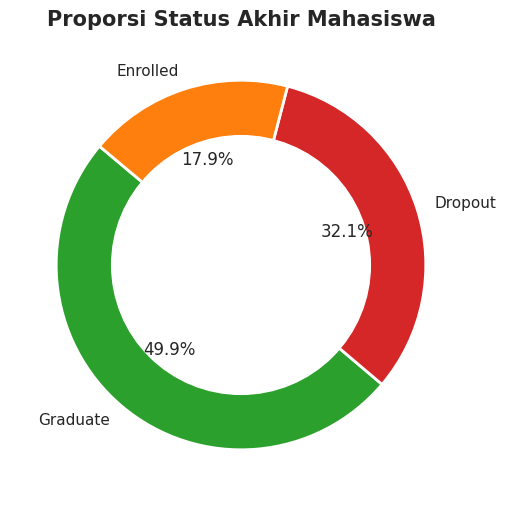

In [26]:
# Mengatur tema visualisasi agar terlihat bersih dan profesional
sns.set_theme(style="whitegrid")

# Visualisasi Distribusi Status Mahasiswa
plt.figure(figsize=(8, 6))

# Menghitung jumlah masing-masing kategori
status_counts = decoded_df['Status'].value_counts()

# Membuat Donut Chart (Pie chart dengan lubang di tengah)
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
        colors=['#2ca02c', '#d62728', '#ff7f0e'], startangle=140,
        wedgeprops={'linewidth': 2, 'edgecolor': 'white'})

# Menambahkan lingkaran putih di tengah
center_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(center_circle)

plt.title('Proporsi Status Akhir Mahasiswa', fontsize=15, fontweight='bold')
plt.show()

**Insight :**
Sebanyak 49,9% mahasiswa berhasil lulus (Graduate), namun terdapat angka Dropout yang cukup signifikan sebesar 32,1%, sementara sisanya masih dalam masa studi (Enrolled).

In [30]:
df.corr()['Status']

,Status
Marital_status,0.100479
Application_mode,0.244507
Application_order,-0.094355
Course,-0.038135
Daytime_evening_attendance,-0.084496
Previous_qualification,0.062323
Previous_qualification_grade,-0.109464
Nacionality,0.015516
Mothers_qualification,0.053989
Fathers_qualification,0.005865


Faktor Pendorong Utama Status Lulus/Dropout

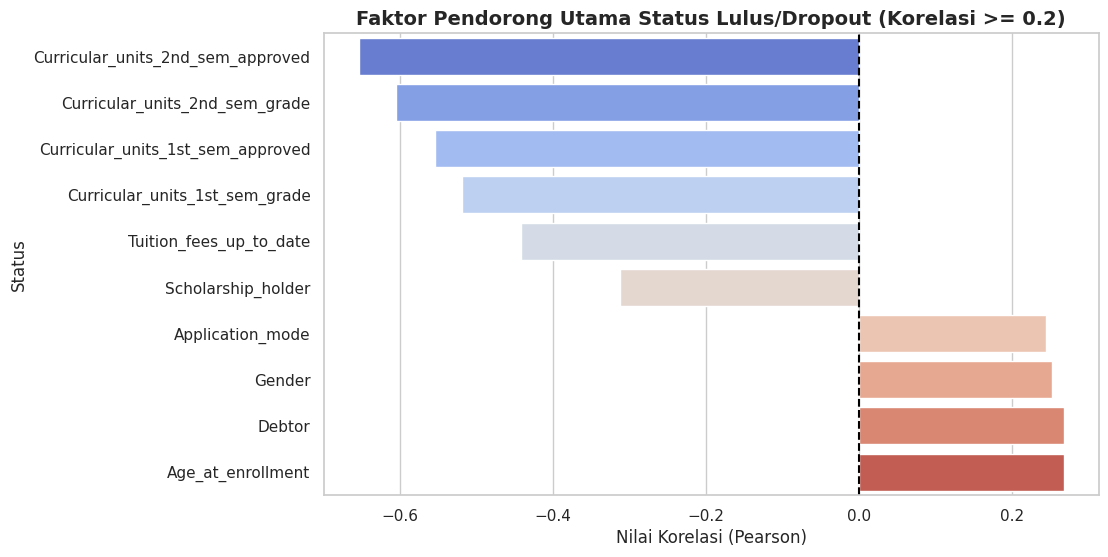

In [31]:
# Analisis Fitur yang Paling Berpengaruh Terhadap Status (Korelasi >= 0.2)
plt.figure(figsize=(10, 6))

# Menghitung korelasi Pearson dan langsung fokus mengambil kolom 'Status' saja
korelasi_status = df.corr()['Status'].drop('Status')

# Memfilter fitur yang memiliki nilai korelasi absolut >= 0.2
fitur_penting = korelasi_status[abs(korelasi_status) >= 0.2].sort_values()

# Membuat Horizontal Bar Chart
sns.barplot(x=fitur_penting.values, y=fitur_penting.index, palette='coolwarm')

plt.title('Faktor Pendorong Utama Status Lulus/Dropout (Korelasi >= 0.2)', fontsize=14, fontweight='bold')
plt.xlabel('Nilai Korelasi (Pearson)')
plt.ylabel('Status')
plt.axvline(x=0, color='black', linestyle='--') # Garis batas nol (Positif vs Negatif)
plt.show()

**Insight :**
Keberhasilan akademik di semester kedua dan status kelancaran pembayaran biaya kuliah merupakan faktor terkuat yang menahan mahasiswa dari risiko dropout.

Membandingkan Kinerja Akademik (SKS Lulus & Nilai) Berdasarkan Status Mahasiswa

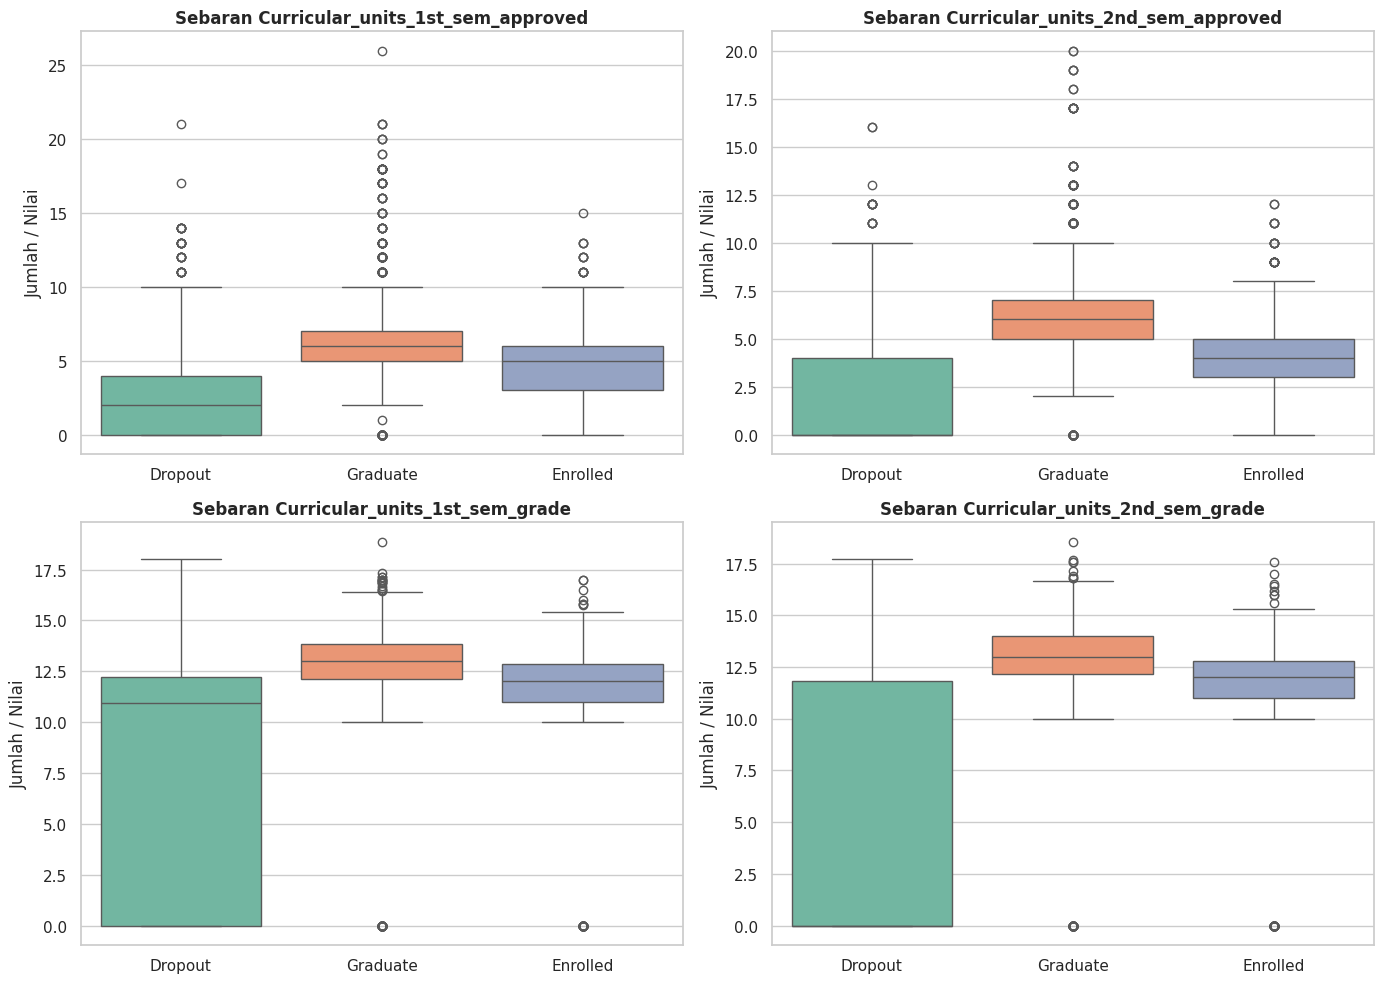

In [28]:
# Menyiapkan canvas 2x2 untuk 4 grafik sekaligus
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Fitur akademik yang ingin dianalisis
akademik_fitur = [
    'Curricular_units_1st_sem_approved', 'Curricular_units_2nd_sem_approved',
    'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_grade'
]

# Looping untuk mengisi masing-masing plot ke dalam grid
for i, fitur in enumerate(akademik_fitur):
    row, col = i // 2, i % 2
    sns.boxplot(data=decoded_df, x='Status', y=fitur, ax=axes[row, col], palette='Set2')

    # Merapikan judul dan label
    axes[row, col].set_title(f'Sebaran {fitur}', fontweight='bold')
    axes[row, col].set_xlabel('')
    axes[row, col].set_ylabel('Jumlah / Nilai')

plt.tight_layout()
plt.show()

**Insight :**
Mahasiswa yang lulus (Graduate) secara konsisten memiliki jumlah unit kurikuler yang disetujui dan nilai rata-rata yang jauh lebih tinggi dibandingkan kelompok Dropout, menunjukkan bahwa performa akademik di tahun pertama merupakan indikator utama keberhasilan studi.

Analisis Demografi dan Finansial Mahasiswa (Categorical Features)

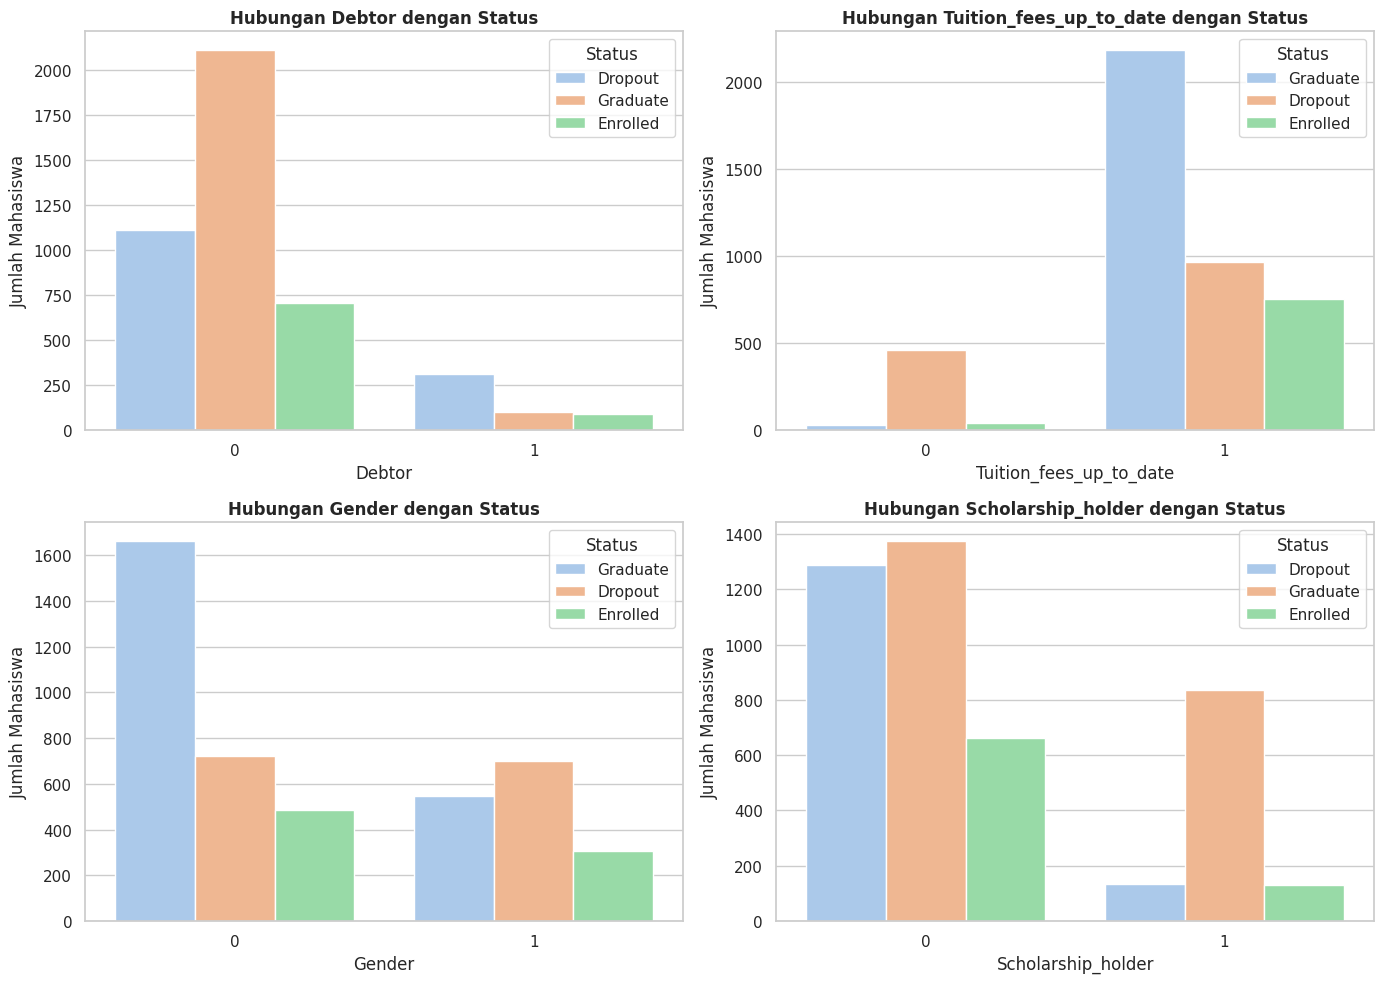

In [29]:
# Kita bandingkan 4 fitur penting terhadap probabilitas kelulusan mereka

kolom_kategorikal = ['Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder']

# Menyiapkan canvas 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, kolom in enumerate(kolom_kategorikal):
    row, col = i // 2, i % 2

    # Membuat Bar plot yang dikelompokkan berdasarkan Status (hue='Status')
    sns.countplot(data=decoded_df, x=kolom, hue='Status', ax=axes[row, col], palette='pastel')

    # Merapikan tampilan
    axes[row, col].set_title(f'Hubungan {kolom} dengan Status', fontweight='bold')
    axes[row, col].set_xlabel(kolom)
    axes[row, col].set_ylabel('Jumlah Mahasiswa')

plt.tight_layout()
plt.show()

**Insight :** Mahasiswa yang memiliki tunggakan biaya kuliah (Debtor) dan belum melunasi biaya pendaftaran (Tuition fees not up to date) memiliki risiko Dropout yang jauh lebih tinggi, sementara kepemilikan beasiswa terbukti menjadi faktor pendukung utama bagi mahasiswa untuk menyelesaikan studinya hingga lulus.

# Data Preparation untuk Machine Learning

In [32]:
# Memilih kolom berdasarkan hasil EDA (korelasi tinggi)
used_cols = [
    'Application_mode', 'Debtor', 'Tuition_fees_up_to_date', 'Gender',
    'Scholarship_holder', 'Age_at_enrollment', 'Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_approved',
    'Curricular_units_2nd_sem_grade', 'Status'
]

# Menggunakan data numerik (df) yang sudah kita bersihkan dari 'Enrolled' di awal
clean_df = df[used_cols].copy()

# Memastikan direktori model tersedia untuk menyimpan scaler/encoder
os.makedirs('./model', exist_ok=True)

In [33]:
def preprocess_data(df):
    df_processed = df.copy()

    # Memisahkan kolom numerik dan kategorikal (kecuali target 'Status')
    numerical_cols = ['Age_at_enrollment', 'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_grade']
    # Sisanya (yang nilainya 0/1 atau kode) dianggap fitur pendukung
    other_cols = [c for c in df_processed.columns if c not in numerical_cols + ['Status']]

    # Proses Scaling untuk angka kontinu
    for col in numerical_cols:
        scaler = MinMaxScaler()
        df_processed[[col]] = scaler.fit_transform(df_processed[[col]])
        joblib.dump(scaler, f'./model/scaler_{col}.joblib') # Simpan untuk kebutuhan dashboard/app

    return df_processed

# Eksekusi preprocessing
new_clean_df = preprocess_data(clean_df)

In [34]:
# Memisahkan Fitur (X) dan Target (y)
X = new_clean_df.drop(columns=['Status'])
y = new_clean_df['Status']

# Menyeimbangkan data agar model tidak bias ke kelas mayoritas
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

# Membagi data: 80% untuk latihan model, 20% untuk uji coba
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

print(f"Jumlah data latih: {X_train.shape[0]}")
print(f"Jumlah data uji: {X_test.shape[0]}")

Jumlah data latih: 3534
Jumlah data uji: 884


## Modeling

=== Memulai Proses Training & Serialization ===

Decision_Tree     | Akurasi: 87.78% | Saved: ./model/decision_tree_model.joblib
Random_Forest     | Akurasi: 89.59% | Saved: ./model/random_forest_model.joblib
Gradient_Boosting | Akurasi: 92.87% | Saved: ./model/gradient_boosting_model.joblib

   HASIL TRAINING & KOMPARASI MODEL
            Model  Accuracy Score
Gradient_Boosting        0.928733
    Random_Forest        0.895928
    Decision_Tree        0.877828


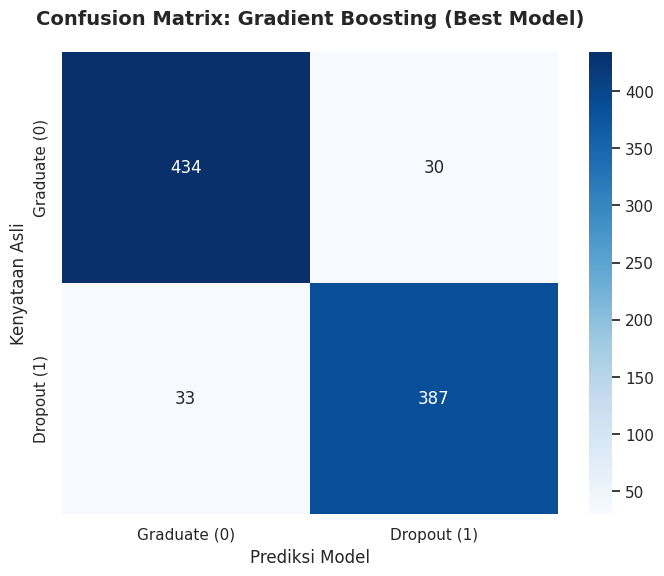

In [37]:
# Menentukan 3 algoritma kandidat dengan hyperparameter optimal
models = {
    "Decision_Tree": DecisionTreeClassifier(
        criterion='gini', max_depth=7, max_features='sqrt', random_state=42
    ),
    "Random_Forest": RandomForestClassifier(
        criterion='entropy', max_depth=8, n_estimators=500, max_features='log2', random_state=42
    ),
    "Gradient_Boosting": GradientBoostingClassifier(
        learning_rate=0.1, max_depth=8, max_features='sqrt', n_estimators=300, random_state=42
    )
}

performance_results = []

print("=== Memulai Proses Training & Serialization ===\n")

for name, model in models.items():
    # Proses Training
    model.fit(X_train, y_train)

    # Simpan Model ke format .joblib (Kriteria 4)
    model_path = f'./model/{name.lower()}_model.joblib'
    joblib.dump(model, model_path)

    # Prediksi untuk evaluasi
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    # Simpan hasil akurasi ke list
    performance_results.append({'Model': name, 'Accuracy Score': acc})

    print(f"{name:17} | Akurasi: {acc:.2%} | Saved: {model_path}")

# Membuat DataFrame ringkasan yang diurutkan dari akurasi tertinggi
summary_df = pd.DataFrame(performance_results).sort_values(by='Accuracy Score', ascending=False)

print("\n" + "="*40)
print("   HASIL TRAINING & KOMPARASI MODEL")
print("="*40)
print(summary_df.to_string(index=False))
print("="*40)

# Mengambil model dengan performa terbaik secara otomatis
best_model_name = summary_df.iloc[0]['Model']
best_model_obj = models[best_model_name]

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, best_model_obj.predict(X_test))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Graduate (0)', 'Dropout (1)'],
            yticklabels=['Graduate (0)', 'Dropout (1)'])

plt.title(f'Confusion Matrix: {best_model_name.replace("_", " ")} (Best Model)',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Prediksi Model', fontsize=12)
plt.ylabel('Kenyataan Asli', fontsize=12)
plt.show()

## Evaluation

Laporan Evaluasi & Confusion Matrix

=== EVALUASI DETAIL MODEL TERBAIK ===
Model Terbaik: Gradient_Boosting
------------------------------
              precision    recall  f1-score   support

Graduate (0)       0.93      0.94      0.93       464
 Dropout (1)       0.93      0.92      0.92       420

    accuracy                           0.93       884
   macro avg       0.93      0.93      0.93       884
weighted avg       0.93      0.93      0.93       884



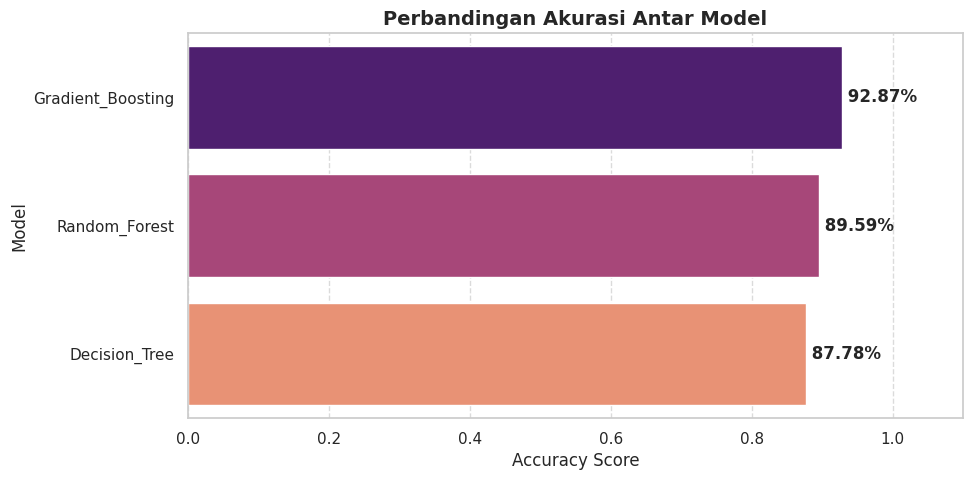

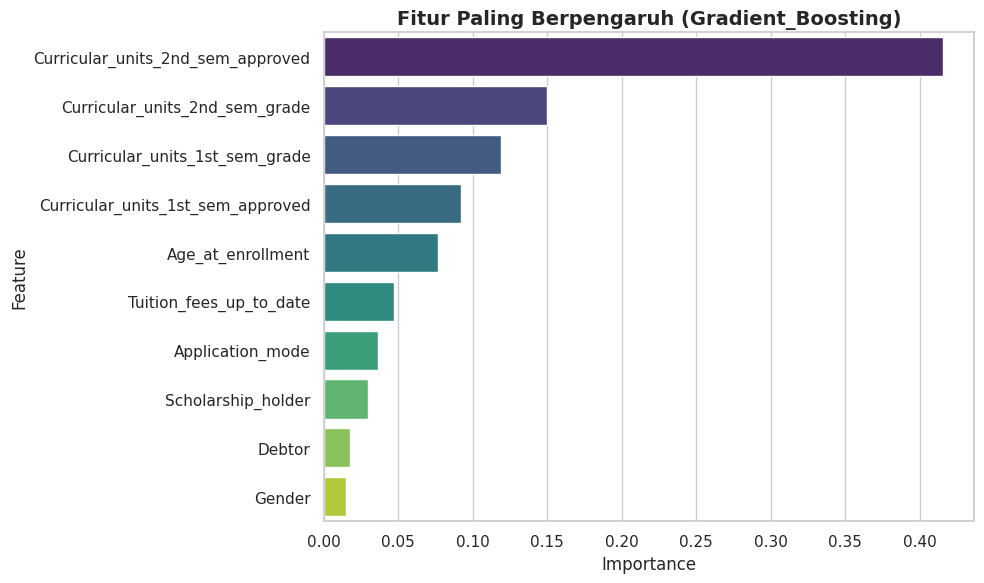

In [39]:
print("=== EVALUASI DETAIL MODEL TERBAIK ===")
# Mengambil model terbaik dari summary_df hasil cell sebelumnya
best_model_name = summary_df.iloc[0]['Model']
best_model = models[best_model_name]

# Melakukan prediksi pada data uji
y_pred_best = best_model.predict(X_test)

# Menampilkan Classification Report
# Ini penting untuk melihat Precision dan Recall tiap kelas (0 dan 1)
print(f"Model Terbaik: {best_model_name}")
print("-" * 30)
print(classification_report(y_test, y_pred_best, target_names=['Graduate (0)', 'Dropout (1)']))

# ==========================================
plt.figure(figsize=(10, 5))
sns.barplot(x='Accuracy Score', y='Model', data=summary_df, palette='magma')

# Menambahkan label angka di ujung bar
for index, value in enumerate(summary_df['Accuracy Score']):
    plt.text(value, index, f' {value:.2%}', va='center', fontweight='bold')

plt.title('Perbandingan Akurasi Antar Model', fontsize=14, fontweight='bold')
plt.xlim(0, 1.1) # Memberikan ruang agar teks tidak terpotong
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Khusus untuk Random Forest atau Gradient Boosting, kita bisa melihat fitur apa yang paling berpengaruh
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feature_names = X.columns
    feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
    plt.title(f'Fitur Paling Berpengaruh ({best_model_name})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [41]:
# Menyimpan data uji + hasil prediksinya ke CSV
test_results = X_test.copy()
test_results['Actual_Status'] = y_test
test_results['Predicted_Status'] = y_pred_best

os.makedirs('./dataset', exist_ok=True)
test_results.to_csv('./dataset/prediction_results.csv', index=False)
print("\Hasil prediksi data uji telah disimpan di: ./dataset/prediction_results.csv")

\Hasil prediksi data uji telah disimpan di: ./dataset/prediction_results.csv
